# Data Overview

### Time range

2007-01-01 to 2026-06-30

---

### Data group: `g10_fx_spot_forward`

**Including:**

* **Currencies:** AUD, CAD, CHF, EUR, GBP, JPY, NOK, NZD, SEK.
* **Optional developed-market currencies:** DKK, HKD.
* **Spot tickers:** `{CCY} Curncy`, such as `EUR Curncy`, `JPY Curncy`, `AUD Curncy`.
* **Forward tenors:** 1W, 1M, 3M, 6M, 12M.
* **Forward tickers:** `{CCY}{TENOR} Curncy`, such as `EUR1M Curncy`, `JPY3M Curncy`, `AUD12M Curncy`.
* **Fields:** `PX_LAST`, `PX_BID`, `PX_ASK`.

**Why it matters:**

This is the core dataset for the project. FX carry returns are primarily built from spot and forward exchange rates. The forward discount or forward-implied interest differential is the basic carry signal, while the future spot movement determines whether the carry trade is profitable.

The 1M forward is the most natural starting point because many academic and practitioner FX carry strategies are rebalanced monthly. Longer tenors such as 3M, 6M, and 12M are useful for testing whether the carry signal is robust across horizons. Bid and ask fields allow the strategy to move from a theoretical gross return to a transaction-cost-adjusted return.

---

### Data group: `em_fx_spot_forward`

**Including:**

* **EM spot currencies:** MXN, ZAR, BRL, KRW, IDR, MYR, PHP, CLP, COP, PEN, SGD, CNH, CNY, INR, THB, PLN, HUF, TRY, ILS.
* **Simple forward convention currencies:** MXN, ZAR, MYR, PHP, SGD, CNH, CNY, THB, PLN, HUF, TRY, ILS.
* **Simple forward tenors:** 1M, 3M, 6M, 12M.
* **Special forward / NDF roots:**

  * BRL NDF: `BCN`
  * KRW onshore forward: `KWO`
  * IDR onshore forward: `IHO`
  * PHP NDF: `PPN`
  * CLP NDF: `CHN`
  * COP NDF: `CLN`
  * PEN NDF: `PSN`
* **INR candidate conventions:** `INR1M`, `INR3M`, `INR6M`, `INR12M`, and `IRN1M`, `IRN3M`, `IRN6M`, `IRN12M`.
* **Fields:** `PX_LAST`, `PX_BID`, `PX_ASK`.

**Why it matters:**

EM currencies are important because FX carry premia are often much stronger in high-yielding emerging-market currencies than in G10 currencies. Adding EM currencies makes the cross-section wider and gives the project more meaningful carry dispersion.

However, EM FX data must be handled carefully. Some currencies are deliverable forwards, while others use NDFs or special Bloomberg conventions. This matters because liquidity, capital controls, convertibility, and offshore/onshore market segmentation can affect measured carry returns. EM data is useful for building a richer carry strategy, but it also requires more careful cleaning and interpretation than G10 data.

---

### Data group: `g10_fx_options`

**Including:**

* **Currency option pairs:** EURUSD, USDJPY, GBPUSD, USDCHF, USDCAD, AUDUSD, NZDUSD, USDNOK, USDSEK, USDDKK, USDHKD.
* **Option tenors:** 1W, 1M, 3M, 6M, 1Y.
* **Option measures:**

  * `V`: ATM implied volatility.
  * `25R`: 25-delta risk reversal.
  * `25B`: 25-delta butterfly.
  * `10R`: 10-delta risk reversal.
  * `10B`: 10-delta butterfly.
* **Ticker structure:** `{PAIR}{OPTION_TYPE}{TENOR} Curncy`, for example:

  * `EURUSDV1M Curncy`
  * `EURUSD25R1M Curncy`
  * `EURUSD25B1M Curncy`
* **Fields:** `PX_LAST`, `PX_BID`, `PX_ASK`.

**Why it matters:**

FX options provide market-implied information about volatility, skewness, and tail risk. This is especially relevant for FX carry because carry strategies often earn small positive returns in calm markets but suffer large losses during risk-off periods.

ATM implied volatility can be used as a volatility-regime filter. Risk reversals can indicate whether the options market is pricing asymmetric crash risk in a currency. Butterflies can help measure smile curvature and demand for tail protection. These option-implied variables can be used to build skew-adjusted or crash-risk-aware carry signals.

---

### Data group: `em_fx_options`

**Including:**

* **Currency option pairs:** USDMXN, USDZAR, USDBRL, USDKRW, USDSGD, USDCNH, USDCNY, USDINR, USDTRY, USDPLN, USDHUF, USDTHB, USDILS.
* **Option tenors:** 1W, 1M, 3M, 6M, 1Y.
* **Option measures:**

  * `V`: ATM implied volatility.
  * `25R`: 25-delta risk reversal.
  * `25B`: 25-delta butterfly.
  * `10R`: 10-delta risk reversal.
  * `10B`: 10-delta butterfly.
* **Ticker structure:** `{PAIR}{OPTION_TYPE}{TENOR} Curncy`.
* **Fields:** `PX_LAST`, `PX_BID`, `PX_ASK`.

**Why it matters:**

EM FX options are useful because EM carry trades are more exposed to crash risk, devaluation risk, liquidity shocks, and global risk-off episodes. Option-implied volatility and skew may help identify when high carry is actually compensation for large downside risk.

This data can support research questions such as whether high-yield EM currencies with expensive downside protection perform worse in future carry returns, or whether option-implied skew helps reduce carry strategy drawdowns.

---

### Data group: `global_risk`

**Including:**

* **Equity volatility:** `VIX Index`.
* **Rates volatility:** `MOVE Index`.
* **US dollar strength:** `DXY Curncy`.
* **Equity risk sentiment:** `SPX Index`, `NDX Index`, `RTY Index`, `MXWO Index`, `MXEF Index`.
* **FX volatility indices:** `JPMVXYGL Index`, `JPMVXYG7 Index`, `JPMVXYEM Index`.
* **Commodities:** `BCOM Index`, `CL1 Comdty`, `CO1 Comdty`, `XAU Curncy`, `HG1 Comdty`.
* **US rates:** `USGG2YR Index`, `USGG10YR Index`, `USYC2Y10 Index`.
* **US macro / financial conditions:** `CPI YOY Index`, `CPURNSA Index`, `GDP CUR$ Index`, `M2% YOY Index`, `BFCIUS Index`, `FEDL01 Index`, `SOFRRATE Index`.
* **Developed-market government yields:** US, Germany, UK, Japan, Canada, and Australia 2Y/10Y yield proxies.
* **EM risks:** `JPEIGLSP Index`: JPM EMBI Global sovereign spread candidate.
* **Fields:** `PX_LAST`.

**Why it matters:**

This group provides the regime and risk-sentiment variables. FX carry is usually sensitive to global risk appetite: it tends to perform better in calm, risk-on environments and worse during volatility spikes, dollar squeezes, equity drawdowns, and funding stress.

VIX and MOVE capture equity and rates uncertainty. DXY captures broad dollar pressure. JPM FX volatility indices directly measure the global FX volatility environment. Equity indices capture risk-on/risk-off regimes, while commodities help explain currencies linked to global growth or commodity exports, such as AUD, CAD, NOK, MXN, BRL, CLP, and ZAR.

---

### Data group: `g10_interest_rates`

**Including:**

* **OIS / swap-style proxies for:** USD, EUR, GBP, JPY, CHF, AUD, CAD, NZD, SEK, plus optional SGD and HKD.
* **IBOR / money-market proxies for:** USD, EUR, GBP, JPY, CHF, AUD, CAD, NOK, NZD, SEK.
* **Example tenors:** 1W, 1M, 3M, 6M, 12M, depending on the market and ticker availability.
* **Fields:** `PX_LAST`.

**Why it matters:**

Interest-rate data helps interpret the economic source of FX carry. The primary carry signal can be computed from spot and forwards, but rate data is useful for understanding whether forward-implied carry is consistent with short-rate differentials.

This group can also support robustness checks, policy-divergence signals, and CIP-basis analysis. However, some legacy IBOR/LIBOR-style tickers may have discontinued histories, so this group should be treated as explanatory rather than the main source of carry returns.

---

### Data group: `em_interest_rates`

**Including:**

* **BRL:** SELIC / DI / swap proxies.
* **MXN:** overnight / TIIE / swap proxies.
* **ZAR:** JIBAR proxies.
* **KRW:** policy, KORIBOR, CD, swap proxies.
* **IDR:** policy, deposit, and swap proxies.
* **MYR:** KLIBOR and swap proxies.
* **PHP:** PHIREF and swap proxies.
* **CLP:** local short-rate and swap proxies.
* **COP:** repo, deposit, and swap proxies.
* **PEN:** Peru reference-rate proxies.
* **Fields:** `PX_LAST`.

**Why it matters:**

EM interest-rate proxies help explain the level and changes of EM carry. They can be used to compare forward-implied carry with local money-market rates, detect potential CIP-basis effects, and study whether changes in policy rates or local funding conditions predict future carry returns.

This group should be used carefully because EM rate tickers are often less standardized and may be affected by local benchmark changes, data availability, and onshore/offshore market segmentation.

---

### Data group: `fx_carry_benchmarks`

**Including:**

* `DBHVG10U Index`: Deutsche Bank G10 FX carry / currency harvest benchmark candidate.
* `FXCTEM8 Index`: EM-8 FX carry benchmark candidate.
* `DBHVBUSI Index`: Deutsche Bank balanced currency harvest benchmark candidate.
* **Fields:** `PX_LAST`.

**Why it matters:**

These benchmark indices are useful for validating the project’s own carry strategy construction. If the self-constructed carry factor behaves very differently from established benchmark indices, that may indicate a problem in quote direction, forward conversion, weighting, or return calculation.

They can also be used to compute information ratios, benchmark-relative performance, and sanity checks for the final strategy. The code marks these tickers as entitlement-dependent and requiring terminal verification. 

---

### Data group: `g10_rates_gaps`

**Including:**

* DKK money-market candidates: `CIBO01M Index`, `CIBO03M Index`.
* HKD money-market candidates: `HIHD01M Index`, `HIHD03M Index`.
* **Fields:** `PX_LAST`.

**Why it matters:**

This group fills gaps for developed-market currencies that are not fully covered by the main G10 interest-rate list. It is useful if DKK and HKD are included in the broader developed-market universe.

However, DKK and HKD are pegged or quasi-pegged currencies, so they are less important for the main carry strategy than freely floating G10 currencies. These tickers are more useful for completeness and robustness checks than for the core strategy.

---

### Data group: `em_onshore_rates`

**Including:**

* HUF: BUBOR 1M and 3M.
* PLN: WIBOR 1M and 3M.
* TRY: TRLIBOR candidate tickers.
* ILS: TELBOR candidate tickers.
* THB: THBFIX candidate tickers.
* INR: MIBOR / MIFOR / overnight MIBOR candidate tickers.
* SGD: SORA overnight.
* CNH: CNH HIBOR 1M and 3M.
* **Fields:** `PX_LAST`.

**Why it matters:**

This group is designed for Phase-2 analysis. It helps compare forward-implied carry with local onshore or offshore funding rates. This is useful for studying CIP deviations, funding frictions, and market segmentation.

For EM currencies, the forward-implied rate may differ from local money-market rates due to capital controls, convertibility constraints, credit risk, liquidity, and offshore/onshore segmentation. These variables should not replace spot-forward carry in the main backtest, but they are valuable for deeper interpretation.

---

### Summary of data roles

| Data group             | Main role in the project                                  |
| ---------------------- | --------------------------------------------------------- |
| `g10_fx_spot_forward`  | Core carry construction                                   |
| `em_fx_spot_forward`   | EM carry extension and high-yield currency universe       |
| `g10_fx_options`       | Volatility, skew, and crash-risk signals                  |
| `em_fx_options`        | EM tail-risk and skew-adjusted carry signals              |
| `global_risk`          | Regime filters and risk-sentiment controls                |
| `g10_interest_rates`   | Policy divergence and rate-differential interpretation    |
| `em_interest_rates`    | EM rate context and robustness checks                     |
| `macro_market_proxies` | Macro, yield, commodity, and financial-condition controls |
| `g10_rates_gaps`       | Completeness for DKK/HKD rate coverage                    |
| `em_onshore_rates`     | CIP-basis and onshore/offshore funding analysis           |



---

# Baseline G10 Carry Strategy: Monthly Rebalancing

### Data checks

* Convert all FX quotes to USD per unit of foreign currency (`USD_PER_CCY`).
* Bloomberg forward quotes are forward points, so they must be converted to outright forwards before calculating carry.
* Use the 1M forward as the baseline tenor because the strategy is rebalanced monthly.

### Carry return per currency

The carry signal is the forward-implied interest-rate differential, measured by the forward discount:

$$
\text{carry}_{t}^{1m} = \frac{S_t}{F_t^{1m}} - 1
$$

The realized 1M forward excess return is:

$$
\text{rx}*{t+1}^{1m} = \frac{S*{t+1}}{F_t^{1m}} - 1
$$

This can be decomposed into the initial carry component and the subsequent spot movement:

$$\frac{S_{t+1}}{F_t} - 1 = \underbrace{\left(\frac{S_t}{F_t} - 1\right)}_{\text{Carry Return}} + \underbrace{\frac{S_{t+1} - S_t}{F_t}}_{\text{FX Return (Spot Movement)}}$$

Log form:
$$
r_{t+1} = \log(S_{t+1}) - \log(F_t) = r_{t+1} =  \underbrace{\log\left(\frac{S_t}{F_t}\right)}_{\text{carry signal}} + \underbrace{\log\left(\frac{S_{t+1}}{S_t}\right)}_{\text{spot log return}} 
$$​

	​



In [1]:
import pandas as pd
from IPython.display import Markdown, display

monthly_panel = pd.read_parquet("data/processed/g10_1m_carry_panel.parquet")

expected_months = pd.date_range(monthly_panel["month_end"].min(), monthly_panel["month_end"].max(), freq="ME")
rows = []
G10_BASELINE = ["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]
for ccy in G10_BASELINE:
    sub = monthly_panel[monthly_panel["currency"] == ccy].copy()
    rows.append({
        "currency": ccy,
        "months": len(sub),
        "first_month": sub["month_end"].min().date().isoformat() if len(sub) else "",
        "last_month": sub["month_end"].max().date().isoformat() if len(sub) else "",
        "avg_carry_signal_1m": sub["carry_signal_1m"].mean() if len(sub) else np.nan,
        "avg_realized_1m_forward_excess_return": sub["realized_1m_forward_excess_return"].mean() if len(sub) else np.nan,
        "missing_spot_months": int(sub["spot_usd_per_ccy"].isna().sum()) if len(sub) else len(expected_months),
        "missing_forward_months": int(sub["forward_1m_usd_per_ccy"].isna().sum()) if len(sub) else len(expected_months),
        "missing_realized_return_months": int(sub["realized_1m_forward_excess_return"].isna().sum()) if len(sub) else len(expected_months),
    })
currency_summary = pd.DataFrame(rows)

display(currency_summary)

display(Markdown("### Average carry by currency"))
display(currency_summary[["currency", "avg_carry_signal_1m"]].sort_values("avg_carry_signal_1m", ascending=False))

display(Markdown("### Average realized forward excess return by currency"))
display(currency_summary[["currency", "avg_realized_1m_forward_excess_return"]].sort_values("avg_realized_1m_forward_excess_return", ascending=False))


,currency,months,first_month,last_month,avg_carry_signal_1m,avg_realized_1m_forward_excess_return,missing_spot_months,missing_forward_months,missing_realized_return_months
0,AUD,234,2007-01-31,2026-06-30,0.001067,0.001213,0,0,1
1,CAD,234,2007-01-31,2026-06-30,-0.000121,-0.000594,0,0,1
2,CHF,234,2007-01-31,2026-06-30,-0.001672,0.000578,0,0,1
3,EUR,234,2007-01-31,2026-06-30,-0.000872,-0.001082,0,0,1
4,GBP,234,2007-01-31,2026-06-30,-0.000119,-0.001492,0,0,1
5,JPY,234,2007-01-31,2026-06-30,-0.001650,-0.002535,0,0,1
6,NOK,234,2007-01-31,2026-06-30,0.000292,-0.001088,0,0,1
7,NZD,234,2007-01-31,2026-06-30,0.001192,0.001063,0,0,1
8,SEK,234,2007-01-31,2026-06-30,-0.000649,-0.001550,0,0,1


### Average carry by currency

,currency,avg_carry_signal_1m
7,NZD,0.001192
0,AUD,0.001067
6,NOK,0.000292
4,GBP,-0.000119
1,CAD,-0.000121
8,SEK,-0.000649
3,EUR,-0.000872
5,JPY,-0.001650
2,CHF,-0.001672


### Average realized forward excess return by currency

,currency,avg_realized_1m_forward_excess_return
0,AUD,0.001213
7,NZD,0.001063
2,CHF,0.000578
1,CAD,-0.000594
3,EUR,-0.001082
6,NOK,-0.001088
4,GBP,-0.001492
8,SEK,-0.001550
5,JPY,-0.002535


## Build Equal-Weight Long-Short Portfolio

For each month:

- sort currencies by `carry_return_1m`
- long the top three currencies, with each long weight equal to `+1/3`
- short the bottom three currencies, with each short weight equal to `-1/3`
- hold all other currencies at zero weight


Return months: 233


### Portfolio returns

,month_end,portfolio_return,n_currencies,long_currencies,short_currencies,gross_long_weight,gross_short_weight,net_weight,gross_weight,wealth_index,cumulative_return,running_peak,drawdown,rolling_12m_return
0,2007-01-31,0.002329,9,"AUD, GBP, NZD","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.002329,0.002329,1.002329,0.0,NaN
1,2007-02-28,0.015620,9,"AUD, GBP, NZD","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.017985,0.017985,1.017985,0.0,NaN
2,2007-03-31,0.018530,9,"AUD, GBP, NZD","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.036848,0.036848,1.036848,0.0,NaN
3,2007-04-30,0.019652,9,"AUD, GBP, NZD","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.057225,0.057225,1.057225,0.0,NaN
4,2007-05-31,0.032373,9,"AUD, GBP, NZD","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.091451,0.091451,1.091451,0.0,NaN


,month_end,portfolio_return,n_currencies,long_currencies,short_currencies,gross_long_weight,gross_short_weight,net_weight,gross_weight,wealth_index,cumulative_return,running_peak,drawdown,rolling_12m_return
228,2026-01-31,0.014207,9,"AUD, GBP, NOK","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.379830,0.379830,1.379830,0.000000,0.052179
229,2026-02-28,0.013742,9,"AUD, GBP, NOK","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.398791,0.398791,1.398791,0.000000,0.061760
230,2026-03-31,0.022149,9,"AUD, GBP, NOK","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.429773,0.429773,1.429773,0.000000,0.115840
231,2026-04-30,0.004491,9,"AUD, GBP, NOK","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.436195,0.436195,1.436195,0.000000,0.107041
232,2026-05-31,-0.002809,9,"AUD, GBP, NOK","CHF, JPY, SEK",1.0,-1.0,-5.551115e-17,2.0,1.432161,0.432161,1.436195,-0.002809,0.107446


### Performance summary

,months,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,skewness,hit_rate,best_month,worst_month
0,233,1.87%,7.80%,0.24,-27.26%,-0.76,57.08%,7.56%,-11.60%


### Worst 10 months

,month_end,portfolio_return,long_currencies,short_currencies,drawdown,explanation
20,2008-09-30 00:00:00,-11.60%,"AUD, NOK, NZD","CHF, EUR, JPY",-22.35%,Global Financial Crisis
157,2020-02-29 00:00:00,-6.41%,"CAD, NOK, NZD","CHF, EUR, JPY",-13.23%,COVID
19,2008-08-31 00:00:00,-6.32%,"AUD, NOK, NZD","CAD, CHF, JPY",-12.16%,Global Financial Crisis
95,2014-12-31 00:00:00,-6.04%,"AUD, NOK, NZD","CHF, EUR, JPY",-8.94%,Crude Oil Price Crash
142,2018-11-30 00:00:00,-5.13%,"AUD, CAD, NZD","CHF, JPY, SEK",-7.17%,US-China Trade War Escalation
9,2007-10-31 00:00:00,-4.51%,"AUD, GBP, NZD","CHF, EUR, JPY",-4.78%,Quant Meltdown
55,2011-08-31 00:00:00,-4.16%,"AUD, NOK, NZD","CHF, GBP, JPY",-9.58%,US Credit Rating Downgrade
76,2013-05-31 00:00:00,-4.11%,"AUD, NOK, NZD","CHF, EUR, JPY",-7.00%,The Taper Tantrum
187,2022-08-31 00:00:00,-3.96%,"AUD, CAD, NZD","CHF, EUR, JPY",-3.96%,Hawkish Jackson Hole Speech
39,2010-04-30 00:00:00,-3.91%,"AUD, NOK, NZD","CHF, JPY, SEK",-8.14%,Eurozone Debt Crisis Flare-up


### Performance by calendar year

,year,months,calendar_year_return,annualized_volatility,sharpe_ratio,hit_rate,max_drawdown
0,2007,12,1.41%,9.06%,0.16,58.33%,-7.09%
1,2008,12,-21.71%,13.54%,-1.60,33.33%,-24.64%
2,2009,12,25.48%,8.46%,3.01,83.33%,-1.69%
3,2010,12,1.34%,9.23%,0.15,50.00%,-7.50%
4,2011,12,6.11%,8.42%,0.73,50.00%,-6.15%
5,2012,12,9.57%,7.88%,1.21,66.67%,-5.71%
6,2013,12,-5.36%,7.41%,-0.72,41.67%,-8.97%
7,2014,12,-0.84%,7.83%,-0.11,58.33%,-7.70%
8,2015,12,-1.34%,9.28%,-0.14,33.33%,-10.74%
9,2016,12,7.82%,4.22%,1.85,66.67%,-1.57%


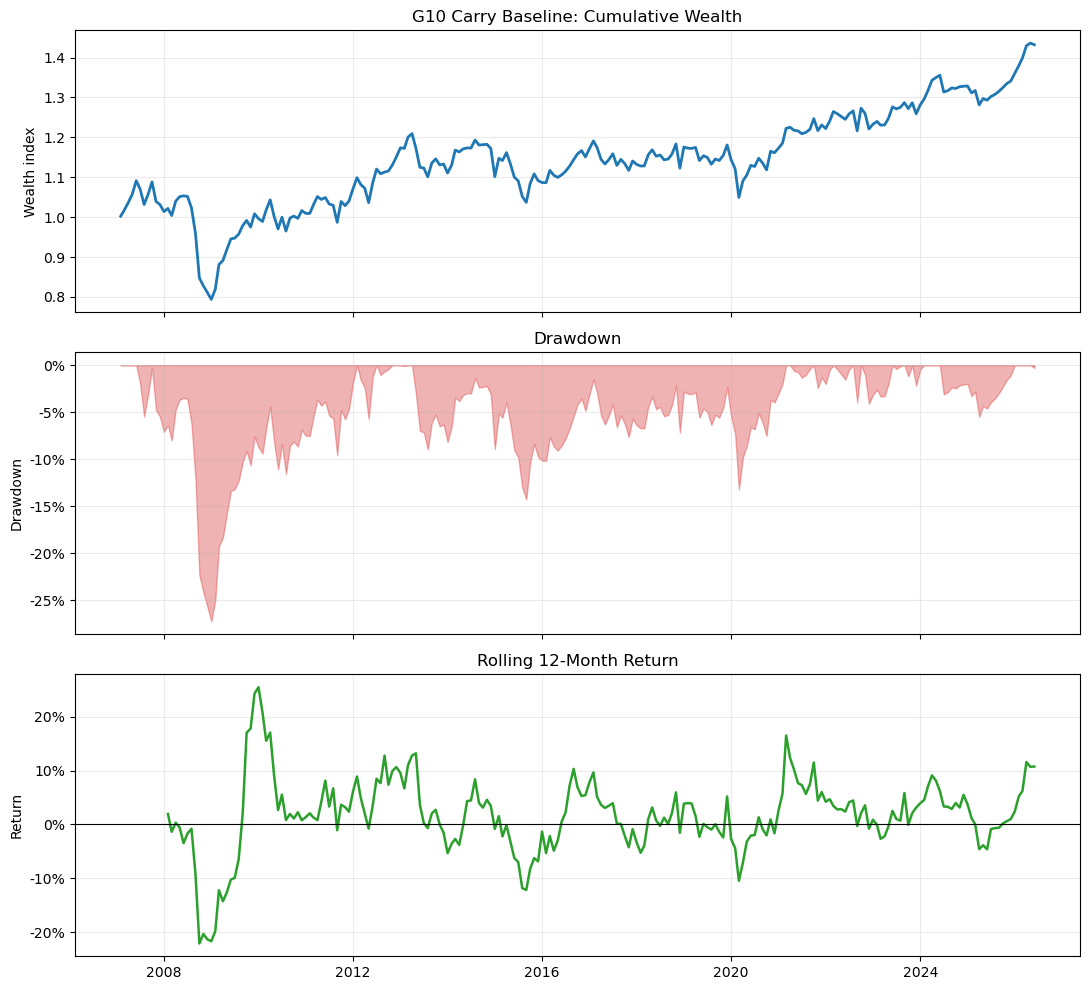

In [3]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start] + list(start.parents):
        if (candidate / "theo" / "data" / "processed").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing theo/data/processed and data/.")


ROOT = find_project_root()
PANEL_PATH = ROOT / "theo" / "data" / "processed" / "g10_1m_carry_panel.parquet"
G10_BASELINE = ["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]
TOP_N = 3
BOTTOM_N = 3
MONTHS_PER_YEAR = 12

def load_panel(path):
    if not path.exists():
        warnings.warn(f"Missing processed panel: {path}")
        return pd.DataFrame(), {"loaded": False, "rows": 0, "message": "missing file"}
    try:
        panel = pd.read_parquet(path)
        panel["month_end"] = pd.to_datetime(panel["month_end"], errors="coerce")
        numeric_cols = ["carry_signal_1m", "realized_1m_forward_excess_return", "spot_usd_per_ccy", "forward_1m_usd_per_ccy"]
        for col in numeric_cols:
            if col in panel.columns:
                panel[col] = pd.to_numeric(panel[col], errors="coerce")
        panel = panel[panel["currency"].isin(G10_BASELINE)].copy()
        panel = panel.sort_values(["month_end", "currency"])
        return panel, {"loaded": True, "rows": len(panel), "message": ""}
    except Exception as exc:
        warnings.warn(f"Could not load processed panel: {repr(exc)}")
        return pd.DataFrame(), {"loaded": False, "rows": 0, "message": repr(exc)}


panel, load_status = load_panel(PANEL_PATH)

required_cols = ["month_end", "currency", "carry_signal_1m", "realized_1m_forward_excess_return"]
missing_required_cols = [c for c in required_cols if c not in panel.columns]
if missing_required_cols:
    warnings.warn(f"Panel is missing required columns: {missing_required_cols}")

if panel.empty or missing_required_cols:
    coverage_by_month = pd.DataFrame(columns=["month_end", "n_currencies", "n_valid_signal", "n_valid_return", "n_valid_both"])
    coverage_by_currency = pd.DataFrame(columns=["currency", "months", "missing_signal", "missing_realized_return", "first_month", "last_month"])
else:
    tmp = panel.copy()
    tmp["valid_signal"] = tmp["carry_signal_1m"].notna()
    tmp["valid_return"] = tmp["realized_1m_forward_excess_return"].notna()
    tmp["valid_both"] = tmp["valid_signal"] & tmp["valid_return"]
    coverage_by_month = (tmp.groupby("month_end")
        .agg(
            n_currencies=("currency", "nunique"),
            n_valid_signal=("valid_signal", "sum"),
            n_valid_return=("valid_return", "sum"),
            n_valid_both=("valid_both", "sum"),
        )
        .reset_index())
    coverage_by_currency = (tmp.groupby("currency")
        .agg(
            months=("month_end", "nunique"),
            missing_signal=("carry_signal_1m", lambda x: int(x.isna().sum())),
            missing_realized_return=("realized_1m_forward_excess_return", lambda x: int(x.isna().sum())),
            first_month=("month_end", "min"),
            last_month=("month_end", "max"),
        )
        .reset_index())
    coverage_by_currency["first_month"] = coverage_by_currency["first_month"].dt.date.astype(str)
    coverage_by_currency["last_month"] = coverage_by_currency["last_month"].dt.date.astype(str)

def assign_carry_weights(month_df, top_n=TOP_N, bottom_n=BOTTOM_N):
    sub = month_df.dropna(subset=["carry_signal_1m", "realized_1m_forward_excess_return"]).copy()
    sub = sub.sort_values(["carry_signal_1m", "currency"], ascending=[True, True])
    sub["weight"] = 0.0
    sub["basket"] = "middle"

    if len(sub) < top_n + bottom_n:
        sub["basket"] = "insufficient_data"
        return sub

    low_idx = sub.head(bottom_n).index
    high_idx = sub.tail(top_n).index
    sub.loc[low_idx, "weight"] = -1.0 / bottom_n
    sub.loc[low_idx, "basket"] = "short_low_carry"
    sub.loc[high_idx, "weight"] = 1.0 / top_n
    sub.loc[high_idx, "basket"] = "long_high_carry"
    return sub


if panel.empty or missing_required_cols:
    weights_panel = pd.DataFrame(columns=list(panel.columns) + ["weight", "basket", "weighted_return"])
else:
    pieces = []
    for month_end, month_df in panel.groupby("month_end", sort=True):
        assigned = assign_carry_weights(month_df)
        assigned["month_end"] = month_end
        pieces.append(assigned)
    weights_panel = pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame(columns=list(panel.columns) + ["weight", "basket"])
    weights_panel["weighted_return"] = weights_panel["weight"] * weights_panel["realized_1m_forward_excess_return"]

if not weights_panel.empty:
    weights_panel = weights_panel.sort_values(["month_end", "weight", "currency"], ascending=[True, True, True])

def build_portfolio_returns(weights):
    if weights.empty:
        return pd.DataFrame(columns=[
            "month_end", "portfolio_return", "n_currencies", "long_currencies", "short_currencies",
            "gross_long_weight", "gross_short_weight", "net_weight", "gross_weight",
        ])
    rows = []
    for dt, sub in weights.groupby("month_end"):
        long_names = sorted(sub.loc[sub["basket"] == "long_high_carry", "currency"].tolist())
        short_names = sorted(sub.loc[sub["basket"] == "short_low_carry", "currency"].tolist())
        rows.append({
            "month_end": dt,
            "portfolio_return": sub["weighted_return"].sum(),
            "n_currencies": sub["currency"].nunique(),
            "long_currencies": ", ".join(long_names),
            "short_currencies": ", ".join(short_names),
            "gross_long_weight": sub.loc[sub["weight"] > 0, "weight"].sum(),
            "gross_short_weight": sub.loc[sub["weight"] < 0, "weight"].sum(),
            "net_weight": sub["weight"].sum(),
            "gross_weight": sub["weight"].abs().sum(),
        })
    out = pd.DataFrame(rows).sort_values("month_end")
    valid_weights = (
        np.isclose(out["gross_long_weight"], 1.0)
        & np.isclose(out["gross_short_weight"], -1.0)
        & np.isclose(out["net_weight"], 0.0)
        & np.isclose(out["gross_weight"], 2.0)
    )
    out = out[valid_weights].copy()
    out["wealth_index"] = (1.0 + out["portfolio_return"]).cumprod()
    out["cumulative_return"] = out["wealth_index"] - 1.0
    out["running_peak"] = out["wealth_index"].cummax()
    out["drawdown"] = out["wealth_index"] / out["running_peak"] - 1.0
    out["rolling_12m_return"] = out["wealth_index"] / out["wealth_index"].shift(12) - 1.0
    return out


portfolio_returns = build_portfolio_returns(weights_panel)
print(f"Return months: {len(portfolio_returns):,}")
display(Markdown("### Portfolio returns"))
display(portfolio_returns.head())
display(portfolio_returns.tail())

def max_drawdown(return_series):
    if return_series.empty:
        return np.nan
    wealth = (1.0 + return_series).cumprod()
    dd = wealth / wealth.cummax() - 1.0
    return dd.min()


def performance_summary(returns, months_per_year=MONTHS_PER_YEAR):
    r = returns.dropna().astype(float)
    if r.empty:
        return pd.DataFrame([{
            "months": 0,
            "annualized_return": np.nan,
            "annualized_volatility": np.nan,
            "sharpe_ratio": np.nan,
            "max_drawdown": np.nan,
            "skewness": np.nan,
            "hit_rate": np.nan,
        }])
    compounded_annual_return = (1.0 + r).prod() ** (months_per_year / len(r)) - 1.0
    annual_vol = r.std(ddof=1) * np.sqrt(months_per_year)
    sharpe = compounded_annual_return / annual_vol if annual_vol and pd.notna(annual_vol) else np.nan
    return pd.DataFrame([{
        "months": len(r),
        "annualized_return": compounded_annual_return,
        "annualized_volatility": annual_vol,
        "sharpe_ratio": sharpe,
        "max_drawdown": max_drawdown(r),
        "skewness": r.skew(),
        "hit_rate": (r > 0).mean(),
        "best_month": r.max(),
        "worst_month": r.min(),
    }])

display(Markdown("### Performance summary"))
summary = performance_summary(portfolio_returns["portfolio_return"] if not portfolio_returns.empty else pd.Series(dtype=float))
display(summary.style.format({
    "annualized_return": "{:.2%}",
    "annualized_volatility": "{:.2%}",
    "sharpe_ratio": "{:.2f}",
    "max_drawdown": "{:.2%}",
    "skewness": "{:.2f}",
    "hit_rate": "{:.2%}",
    "best_month": "{:.2%}",
    "worst_month": "{:.2%}",
}))

if portfolio_returns.empty:
    worst_10_months = pd.DataFrame(columns=["month_end", "portfolio_return", "long_currencies", "short_currencies"])
    yearly_performance = pd.DataFrame(columns=["year", "months", "calendar_year_return", "annualized_volatility", "sharpe_ratio", "hit_rate", "max_drawdown"])
else:
    worst_10_months = (portfolio_returns
        .sort_values("portfolio_return")
        .head(10)
        [["month_end", "portfolio_return", "long_currencies", "short_currencies", "drawdown"]]
        .copy())

    yr = portfolio_returns.copy()
    yr["year"] = yr["month_end"].dt.year
    rows = []
    for year, sub in yr.groupby("year"):
        r = sub["portfolio_return"].dropna()
        vol = r.std(ddof=1) * np.sqrt(MONTHS_PER_YEAR) if len(r) > 1 else np.nan
        year_return = (1.0 + r).prod() - 1.0 if len(r) else np.nan
        rows.append({
            "year": year,
            "months": len(r),
            "calendar_year_return": year_return,
            "annualized_volatility": vol,
            "sharpe_ratio": year_return / vol if vol and pd.notna(vol) else np.nan,
            "hit_rate": (r > 0).mean() if len(r) else np.nan,
            "max_drawdown": max_drawdown(r),
        })
    yearly_performance = pd.DataFrame(rows)

worst_10_months_explaination = [
    "Global Financial Crisis",
    "COVID",
    "Global Financial Crisis",
    "Crude Oil Price Crash",
    "US-China Trade War Escalation",
    "Quant Meltdown",
    "US Credit Rating Downgrade",
    "The Taper Tantrum",
    "Hawkish Jackson Hole Speech",
    "Eurozone Debt Crisis Flare-up",
]
worst_10_months['explanation'] = worst_10_months_explaination

display(Markdown("### Worst 10 months"))
display(worst_10_months.style.format({"portfolio_return": "{:.2%}", "drawdown": "{:.2%}"}) if not worst_10_months.empty else worst_10_months)

display(Markdown("### Performance by calendar year"))
display(yearly_performance.style.format({
    "calendar_year_return": "{:.2%}",
    "annualized_volatility": "{:.2%}",
    "sharpe_ratio": "{:.2f}",
    "hit_rate": "{:.2%}",
    "max_drawdown": "{:.2%}",
}) if not yearly_performance.empty else yearly_performance)

if plt is None or portfolio_returns.empty:
    display(Markdown("Performance plots skipped because matplotlib is unavailable or no portfolio returns were created."))
else:
    fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

    axes[0].plot(portfolio_returns["month_end"], portfolio_returns["wealth_index"], color="#1f77b4", linewidth=2)
    axes[0].set_title("G10 Carry Baseline: Cumulative Wealth")
    axes[0].set_ylabel("Wealth index")
    axes[0].grid(alpha=0.25)

    axes[1].fill_between(portfolio_returns["month_end"], portfolio_returns["drawdown"], 0, color="#d62728", alpha=0.35)
    axes[1].set_title("Drawdown")
    axes[1].set_ylabel("Drawdown")
    axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    axes[1].grid(alpha=0.25)

    axes[2].plot(portfolio_returns["month_end"], portfolio_returns["rolling_12m_return"], color="#2ca02c", linewidth=1.8)
    axes[2].axhline(0, color="black", linewidth=0.8)
    axes[2].set_title("Rolling 12-Month Return")
    axes[2].set_ylabel("Return")
    axes[2].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    axes[2].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


# Transaction Cost Analysis

- Rebalancing cost only charges the change in portfolio weights from one month to the next.
- Forward-roll cost charges the full gross notional that must be rolled each month because the strategy holds 1M forwards.

,scenario,months,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,skewness,hit_rate,final_cumulative_return,annualized_cost_drag,note
0,Gross,233,1.87%,7.80%,0.24,-27.26%,-0.76,57.08%,43.22%,0.00%,zero transaction-cost baseline
1,Rebalancing cost 1bp,233,1.84%,7.80%,0.24,-27.29%,-0.76,57.08%,42.40%,0.03%,1bp per unit of rebalancing turnover
2,Rebalancing cost 2bp,233,1.81%,7.80%,0.23,-27.32%,-0.76,57.08%,41.58%,0.06%,2bp per unit of rebalancing turnover
3,Rebalancing cost 5bp,233,1.72%,7.80%,0.22,-27.42%,-0.76,57.08%,39.17%,0.15%,5bp per unit of rebalancing turnover
4,Roll cost 1bp,233,1.62%,7.80%,0.21,-27.55%,-0.76,56.65%,36.70%,0.24%,1bp per unit of monthly gross roll notional
5,Roll cost 2bp,233,1.38%,7.80%,0.18,-27.83%,-0.76,56.22%,30.48%,0.48%,2bp per unit of monthly gross roll notional
6,Roll cost 5bp,233,0.65%,7.80%,0.08,-28.66%,-0.76,54.51%,13.47%,1.20%,5bp per unit of monthly gross roll notional
7,Roll cost 10bp,233,-0.55%,7.80%,-0.07,-30.03%,-0.76,53.65%,-10.12%,2.40%,10bp per unit of monthly gross roll notional


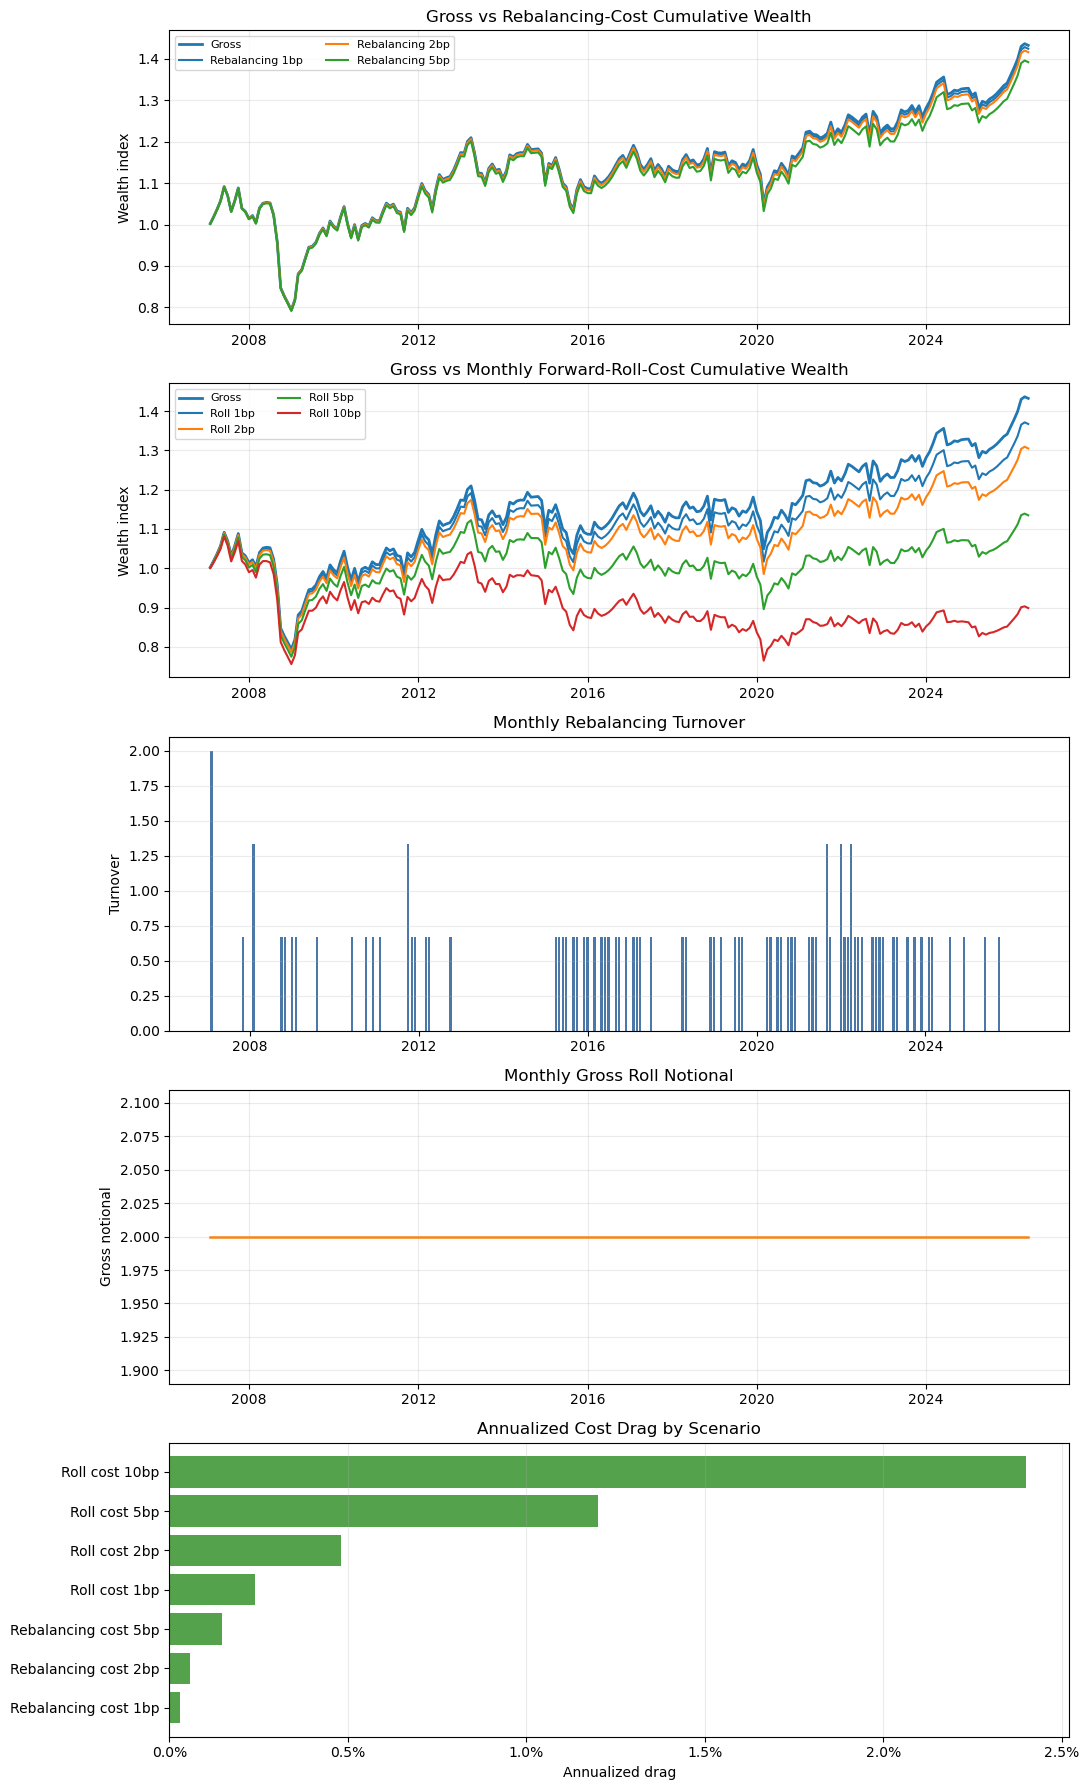

In [14]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start] + list(start.parents):
        if (candidate / "theo" / "data" / "processed").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing theo/data/processed and data/.")


ROOT = find_project_root()
PANEL_PATH = ROOT / "theo" / "data" / "processed" / "g10_1m_carry_panel.parquet"
G10_BASELINE = ["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]
TOP_N = 3
BOTTOM_N = 3
MONTHS_PER_YEAR = 12
REBALANCING_COST_BPS = [1, 2, 5]
ROLL_COST_BPS = [1, 2, 5, 10]

def load_panel(path):
    if not path.exists():
        warnings.warn(f"Missing processed panel: {path}")
        return pd.DataFrame(), {"loaded": False, "rows": 0, "message": "missing file"}
    try:
        panel = pd.read_parquet(path)
        panel["month_end"] = pd.to_datetime(panel["month_end"], errors="coerce")
        for col in ["carry_signal_1m", "realized_1m_forward_excess_return", "spot_usd_per_ccy", "forward_1m_usd_per_ccy"]:
            if col in panel.columns:
                panel[col] = pd.to_numeric(panel[col], errors="coerce")
        panel = panel[panel["currency"].isin(G10_BASELINE)].copy()
        panel = panel.sort_values(["month_end", "currency"])
        return panel, {"loaded": True, "rows": len(panel), "message": ""}
    except Exception as exc:
        warnings.warn(f"Could not load processed panel: {repr(exc)}")
        return pd.DataFrame(), {"loaded": False, "rows": 0, "message": repr(exc)}


panel, load_status = load_panel(PANEL_PATH)

spread_like_cols = [c for c in panel.columns if any(token in c.lower() for token in ["bid", "ask", "spread"])] if not panel.empty else []
spread_status = pd.DataFrame([{
    "bid_ask_or_spread_columns_present": bool(spread_like_cols),
    "columns": ", ".join(spread_like_cols),
    "use_spread_based_costs": False,
    "note": "Fixed-bps scenarios used; spread-based costs require bid/ask columns in the processed panel.",
}])

required_cols = ["month_end", "currency", "carry_signal_1m", "realized_1m_forward_excess_return"]
missing_required_cols = [c for c in required_cols if c not in panel.columns]
if missing_required_cols:
    warnings.warn(f"Panel is missing required columns: {missing_required_cols}")


def assign_carry_weights(month_df, top_n=TOP_N, bottom_n=BOTTOM_N):
    sub = month_df.dropna(subset=["carry_signal_1m", "realized_1m_forward_excess_return"]).copy()
    sub = sub.sort_values(["carry_signal_1m", "currency"], ascending=[True, True])
    sub["weight"] = 0.0
    sub["basket"] = "middle"

    if len(sub) < top_n + bottom_n:
        sub["basket"] = "insufficient_data"
        return sub

    low_idx = sub.head(bottom_n).index
    high_idx = sub.tail(top_n).index
    sub.loc[low_idx, "weight"] = -1.0 / bottom_n
    sub.loc[low_idx, "basket"] = "short_low_carry"
    sub.loc[high_idx, "weight"] = 1.0 / top_n
    sub.loc[high_idx, "basket"] = "long_high_carry"
    return sub


if panel.empty or missing_required_cols:
    weights_panel = pd.DataFrame(columns=list(panel.columns) + ["weight", "basket", "weighted_return"])
else:
    pieces = []
    for month_end, month_df in panel.groupby("month_end", sort=True):
        assigned = assign_carry_weights(month_df)
        assigned["month_end"] = month_end
        pieces.append(assigned)
    weights_panel = pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame(columns=list(panel.columns) + ["weight", "basket"])
    weights_panel = weights_panel.sort_values(["month_end", "currency"])
    weights_panel["weighted_return"] = weights_panel["weight"] * weights_panel["realized_1m_forward_excess_return"]

weights_panel = weights_panel.sort_values(["month_end", "weight", "currency"], ascending=[True, True, True]) if not weights_panel.empty else weights_panel

def attach_rebalancing_turnover(weights):
    if weights.empty:
        return weights.copy(), pd.DataFrame(columns=["month_end", "rebalancing_turnover"])

    weights_wide = weights.pivot_table(index="month_end", columns="currency", values="weight", aggfunc="last").fillna(0.0).sort_index()
    prev_wide = weights_wide.shift(1).fillna(0.0)
    trade_wide = weights_wide - prev_wide

    prev_long = prev_wide.stack().rename("prev_weight").reset_index()
    trade_long = trade_wide.stack().rename("rebalancing_trade").reset_index()
    out = weights.merge(prev_long, on=["month_end", "currency"], how="left")
    out = out.merge(trade_long, on=["month_end", "currency"], how="left")
    out["prev_weight"] = out["prev_weight"].fillna(0.0)
    out["rebalancing_trade"] = out["rebalancing_trade"].fillna(out["weight"])
    out["abs_rebalancing_trade"] = out["rebalancing_trade"].abs()

    monthly = out.groupby("month_end", sort=True)["abs_rebalancing_trade"].sum().rename("rebalancing_turnover").reset_index()
    return out, monthly


weights_panel, monthly_rebalancing = attach_rebalancing_turnover(weights_panel)
monthly_rebalancing["rolling_12m_rebalancing_turnover"] = monthly_rebalancing["rebalancing_turnover"].rolling(12, min_periods=6).mean() if not monthly_rebalancing.empty else pd.Series(dtype=float)

if monthly_rebalancing.empty:
    rebalancing_summary = pd.DataFrame([{"months": 0, "average_monthly_rebalancing_turnover": np.nan, "median_rebalancing_turnover": np.nan, "annualized_rebalancing_turnover": np.nan}])
else:
    rebalancing_summary = pd.DataFrame([{
        "months": len(monthly_rebalancing),
        "average_monthly_rebalancing_turnover": monthly_rebalancing["rebalancing_turnover"].mean(),
        "median_rebalancing_turnover": monthly_rebalancing["rebalancing_turnover"].median(),
        "annualized_rebalancing_turnover": monthly_rebalancing["rebalancing_turnover"].mean() * 12,
    }])

# display(rebalancing_summary)

# display(Markdown("### Worst rebalancing-turnover months"))
# display(monthly_rebalancing.sort_values("rebalancing_turnover", ascending=False).head(12))

if weights_panel.empty:
    currency_activity = pd.DataFrame(columns=["currency", "total_abs_rebalancing_trade", "average_abs_rebalancing_trade", "months_traded", "long_selection_rate", "short_selection_rate"])
else:
    active = weights_panel.copy()
    active["is_long"] = (active["basket"] == "long_high_carry").astype(float)
    active["is_short"] = (active["basket"] == "short_low_carry").astype(float)
    active["was_rebalanced"] = active["abs_rebalancing_trade"] > 1e-12
    currency_activity = (active.groupby("currency")
        .agg(
            total_abs_rebalancing_trade=("abs_rebalancing_trade", "sum"),
            average_abs_rebalancing_trade=("abs_rebalancing_trade", "mean"),
            months_traded=("was_rebalanced", "sum"),
            long_selection_rate=("is_long", "mean"),
            short_selection_rate=("is_short", "mean"),
        )
        .reset_index()
        .sort_values("total_abs_rebalancing_trade", ascending=False))

# display(currency_activity.style.format({
#     "total_abs_rebalancing_trade": "{:.2f}",
#     "average_abs_rebalancing_trade": "{:.3f}",
#     "long_selection_rate": "{:.1%}",
#     "short_selection_rate": "{:.1%}",
# }) if not currency_activity.empty else currency_activity)

def build_portfolio_frame(weights, monthly_rebalancing):
    if weights.empty:
        return pd.DataFrame(columns=["month_end", "gross_return", "gross_roll_notional"])

    rows = []
    for month_end, sub in weights.groupby("month_end", sort=True):
        rows.append({
            "month_end": month_end,
            "gross_return": sub["weighted_return"].sum(),
            "gross_roll_notional": sub["weight"].abs().sum(),
            "gross_long_weight": sub.loc[sub["weight"] > 0, "weight"].sum(),
            "gross_short_weight": sub.loc[sub["weight"] < 0, "weight"].sum(),
            "net_weight": sub["weight"].sum(),
            "long_currencies": ", ".join(sorted(sub.loc[sub["basket"] == "long_high_carry", "currency"].tolist())),
            "short_currencies": ", ".join(sorted(sub.loc[sub["basket"] == "short_low_carry", "currency"].tolist())),
        })
    out = pd.DataFrame(rows).sort_values("month_end")
    out = out.merge(monthly_rebalancing, on="month_end", how="left")
    valid = (
        np.isclose(out["gross_long_weight"], 1.0)
        & np.isclose(out["gross_short_weight"], -1.0)
        & np.isclose(out["net_weight"], 0.0)
        & np.isclose(out["gross_roll_notional"], 2.0)
    )
    out = out[valid].copy()
    return out


portfolio = build_portfolio_frame(weights_panel, monthly_rebalancing)

if portfolio.empty:
    roll_summary = pd.DataFrame([{"mean_gross_roll_notional": np.nan, "min_gross_roll_notional": np.nan, "max_gross_roll_notional": np.nan}])
else:
    roll_summary = pd.DataFrame([{
        "mean_gross_roll_notional": portfolio["gross_roll_notional"].mean(),
        "min_gross_roll_notional": portfolio["gross_roll_notional"].min(),
        "max_gross_roll_notional": portfolio["gross_roll_notional"].max(),
        "months": len(portfolio),
    }])

# display(roll_summary)
# display(portfolio[["month_end", "gross_roll_notional", "rebalancing_turnover", "gross_return", "long_currencies", "short_currencies"]].head())
# display(portfolio[["month_end", "gross_roll_notional", "rebalancing_turnover", "gross_return", "long_currencies", "short_currencies"]].tail())

def add_cost_scenarios(portfolio):
    out = portfolio.copy()
    if out.empty:
        return out

    out["gross"] = out["gross_return"]
    for bps in REBALANCING_COST_BPS:
        cost_col = f"rebalancing_{bps}bp_cost"
        net_col = f"net_rebalancing_{bps}bp"
        out[cost_col] = out["rebalancing_turnover"] * bps / 10000.0
        out[net_col] = out["gross"] - out[cost_col]

    for bps in ROLL_COST_BPS:
        cost_col = f"roll_{bps}bp_cost"
        net_col = f"net_roll_{bps}bp"
        out[cost_col] = out["gross_roll_notional"] * bps / 10000.0
        out[net_col] = out["gross"] - out[cost_col]

    return out


return_panel = add_cost_scenarios(portfolio)
# display(return_panel.head())

def max_drawdown_with_initial_wealth(return_series):
    r = return_series.dropna().astype(float)
    if r.empty:
        return np.nan
    wealth = pd.concat([pd.Series([1.0], index=["initial"]), (1.0 + r).cumprod()])
    drawdown = wealth / wealth.cummax() - 1.0
    return drawdown.min()


def performance_stats(return_series, scenario, annualized_cost_drag=0.0, note=""):
    r = return_series.dropna().astype(float)
    if r.empty:
        return {
            "scenario": scenario,
            "months": 0,
            "annualized_return": np.nan,
            "annualized_volatility": np.nan,
            "sharpe_ratio": np.nan,
            "max_drawdown": np.nan,
            "skewness": np.nan,
            "hit_rate": np.nan,
            "final_cumulative_return": np.nan,
            "annualized_cost_drag": annualized_cost_drag,
            "note": note,
        }
    annual_return = (1.0 + r).prod() ** (MONTHS_PER_YEAR / len(r)) - 1.0
    annual_vol = r.std(ddof=1) * np.sqrt(MONTHS_PER_YEAR)
    return {
        "scenario": scenario,
        "months": len(r),
        "annualized_return": annual_return,
        "annualized_volatility": annual_vol,
        "sharpe_ratio": annual_return / annual_vol if annual_vol and pd.notna(annual_vol) else np.nan,
        "max_drawdown": max_drawdown_with_initial_wealth(r),
        "skewness": r.skew(),
        "hit_rate": (r > 0).mean(),
        "final_cumulative_return": (1.0 + r).prod() - 1.0,
        "annualized_cost_drag": annualized_cost_drag,
        "note": note,
    }

perf_rows = []
if return_panel.empty:
    performance_table = pd.DataFrame()
else:
    perf_rows.append(performance_stats(return_panel["gross"], "Gross", annualized_cost_drag=0.0, note="zero transaction-cost baseline"))
    for bps in REBALANCING_COST_BPS:
        perf_rows.append(performance_stats(
            return_panel[f"net_rebalancing_{bps}bp"],
            f"Rebalancing cost {bps}bp",
            annualized_cost_drag=return_panel[f"rebalancing_{bps}bp_cost"].mean() * MONTHS_PER_YEAR,
            note=f"{bps}bp per unit of rebalancing turnover",
        ))
    for bps in ROLL_COST_BPS:
        perf_rows.append(performance_stats(
            return_panel[f"net_roll_{bps}bp"],
            f"Roll cost {bps}bp",
            annualized_cost_drag=return_panel[f"roll_{bps}bp_cost"].mean() * MONTHS_PER_YEAR,
            note=f"{bps}bp per unit of monthly gross roll notional",
        ))
    performance_table = pd.DataFrame(perf_rows)

display(performance_table.style.format({
    "annualized_return": "{:.2%}",
    "annualized_volatility": "{:.2%}",
    "sharpe_ratio": "{:.2f}",
    "max_drawdown": "{:.2%}",
    "skewness": "{:.2f}",
    "hit_rate": "{:.2%}",
    "final_cumulative_return": "{:.2%}",
    "annualized_cost_drag": "{:.2%}",
}) if not performance_table.empty else performance_table)

def add_wealth_and_drag(df):
    out = df.copy()
    if out.empty:
        return out
    return_cols = ["gross"] + [f"net_rebalancing_{bps}bp" for bps in REBALANCING_COST_BPS] + [f"net_roll_{bps}bp" for bps in ROLL_COST_BPS]
    for col in return_cols:
        out[f"wealth_{col}"] = (1.0 + out[col].fillna(0.0)).cumprod()
        if col != "gross":
            out[f"drag_vs_gross_{col}"] = out["wealth_gross"] - out[f"wealth_{col}"]
    return out


return_panel = add_wealth_and_drag(return_panel)
wealth_cols = [c for c in return_panel.columns if c.startswith("wealth_")] if not return_panel.empty else []
# display(return_panel[["month_end", "gross", "rebalancing_turnover", "gross_roll_notional"] + [f"net_rebalancing_{bps}bp" for bps in REBALANCING_COST_BPS] + [f"net_roll_{bps}bp" for bps in ROLL_COST_BPS]].head() if not return_panel.empty else return_panel)


if plt is None or return_panel.empty:
    display(Markdown("Plots skipped because matplotlib is unavailable or no return panel was created."))
else:
    fig, axes = plt.subplots(5, 1, figsize=(11, 18), sharex=False)

    axes[0].plot(return_panel["month_end"], return_panel["wealth_gross"], linewidth=2.0, label="Gross", color="#1f77b4")
    for bps in REBALANCING_COST_BPS:
        axes[0].plot(return_panel["month_end"], return_panel[f"wealth_net_rebalancing_{bps}bp"], linewidth=1.5, label=f"Rebalancing {bps}bp")
    axes[0].set_title("Gross vs Rebalancing-Cost Cumulative Wealth")
    axes[0].set_ylabel("Wealth index")
    axes[0].grid(alpha=0.25)
    axes[0].legend(ncol=2, fontsize=8)

    axes[1].plot(return_panel["month_end"], return_panel["wealth_gross"], linewidth=2.0, label="Gross", color="#1f77b4")
    for bps in ROLL_COST_BPS:
        axes[1].plot(return_panel["month_end"], return_panel[f"wealth_net_roll_{bps}bp"], linewidth=1.5, label=f"Roll {bps}bp")
    axes[1].set_title("Gross vs Monthly Forward-Roll-Cost Cumulative Wealth")
    axes[1].set_ylabel("Wealth index")
    axes[1].grid(alpha=0.25)
    axes[1].legend(ncol=2, fontsize=8)

    axes[2].bar(return_panel["month_end"], return_panel["rebalancing_turnover"], width=20, color="#4c78a8")
    axes[2].set_title("Monthly Rebalancing Turnover")
    axes[2].set_ylabel("Turnover")
    axes[2].grid(axis="y", alpha=0.25)

    axes[3].plot(return_panel["month_end"], return_panel["gross_roll_notional"], color="#f58518", linewidth=1.8)
    axes[3].set_title("Monthly Gross Roll Notional")
    axes[3].set_ylabel("Gross notional")
    axes[3].grid(alpha=0.25)

    drag_plot = performance_table[performance_table["scenario"] != "Gross"].copy()
    axes[4].barh(drag_plot["scenario"], drag_plot["annualized_cost_drag"], color="#54a24b")
    axes[4].set_title("Annualized Cost Drag by Scenario")
    axes[4].set_xlabel("Annualized drag")
    axes[4].xaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")
    axes[4].grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()


## Future Directions


### Universe and tenor expansion

* Expand the analysis from G10 currencies to selected EM currencies.
* Compare different forward tenors, such as 1M, 3M, and 6M.
* Evaluate whether the monthly rebalancing frequency is optimal or whether slower rebalancing reduces turnover without materially reducing returns.

### Risk and regime analysis

* Study the strategy’s behavior during risk-off periods, using indicators such as VIX, dollar strength, equity drawdowns, and funding-stress proxies.
* Estimate the strategy’s exposure to global risk factors, including equity market risk, volatility risk, dollar risk, and interest-rate differentials.
* Investigate whether carry returns are compensation for crash risk rather than a stable standalone alpha.

### Signal improvement

* Extend the simple carry signal by adding valuation, momentum, volatility, and risk-sentiment filters.
* Test whether high-carry currencies perform better only when global risk conditions are favorable.
* Explore whether volatility-adjusted carry or Sharpe-like carry signals improve risk-adjusted performance.


I am working on an FX carry strategy project.

The current notebook is:

`theo/05_em_carry_robustness_and_attribution.ipynb`

Please modify this notebook. Do not rewrite it from scratch. Preserve all correct existing calculations, but improve the attribution and plotting structure.

Current issue:
The notebook analyzes portfolio contribution attribution, but several plotting sections are hard-coded to use:

`EM ex-CNH`

For example, contribution plots, concentration plots, and crisis attribution plots use `main_strategy = "EM ex-CNH"` or `plot_strategy = "EM ex-CNH"`.

This is not wrong, because EM ex-CNH is useful for studying whether EM carry is driven by TRY/BRL/ZAR/MXN. However, based on notebook `04_em_carry_extension.ipynb`, `G10 + EM ex-CNH` has the best risk-adjusted performance and is the main candidate portfolio. Therefore, the attribution analysis should primarily focus on `G10 + EM ex-CNH`, while keeping `EM ex-CNH` as a secondary or selectable strategy.

Please make the following changes:

1. Add a configuration section near the top of the notebook.

Use something like:

```python
PRIMARY_ATTRIBUTION_STRATEGY = "G10 + EM ex-CNH"
SECONDARY_ATTRIBUTION_STRATEGIES = ["EM ex-CNH"]
ATTRIBUTION_STRATEGIES_TO_PLOT = [
    PRIMARY_ATTRIBUTION_STRATEGY,
    *SECONDARY_ATTRIBUTION_STRATEGIES,
]
````

Also allow the user to easily change this list to analyze other strategies such as:

* `G10`
* `EM ex-CNH`
* `EM incl-CNH`
* `G10 + EM ex-CNH`

Validate that every selected strategy exists in `baseline_returns["strategy"]`. If a selected strategy does not exist, print a warning and skip it instead of crashing.

2. Replace hard-coded plotting choices.

Search for hard-coded strings such as:

```python
main_strategy = "EM ex-CNH"
plot_strategy = "EM ex-CNH"
```

Replace them with the configurable strategy list.

The notebook should generate attribution plots for the primary strategy first, then secondary strategies.

3. Update the portfolio contribution attribution section.

For each selected strategy in `ATTRIBUTION_STRATEGIES_TO_PLOT`, compute and display:

* cumulative portfolio contribution by currency
* total contribution by currency
* contribution during worst 10 portfolio months
* long-side contribution
* short-side contribution
* contribution during crisis windows
* top positive contributors
* top negative contributors

Use the existing contribution definition:

$$
\text{contribution}_{i,t}
=========================

w_{i,t} r^i_{t+1}
$$

Important markdown formula formatting requirement:
When writing formulas in markdown, make sure they render correctly in Jupyter / VSCode markdown. Use display math with `$$ ... $$`. Do not write broken strings where `\t` becomes a tab. If formulas are inside Python strings, use raw strings like `r""" ... """` or double-escape backslashes.

Add a markdown note that this contribution is an additive monthly approximation:

$$
\text{portfolio return}_t
=========================

\sum_i w_{i,t} r^i_{t+1}
$$

and cumulative contribution is the cumulative sum of monthly contributions, not exact geometric compounding attribution.

4. Make `G10 + EM ex-CNH` the default primary attribution strategy.

The notebook should clearly explain why:

* `G10 + EM ex-CNH` had the best risk-adjusted performance in notebook 04.
* Therefore, it should be the primary portfolio to explain.
* `EM ex-CNH` remains important as a secondary diagnostic because it isolates the EM carry premium and tests whether EM performance is concentrated in a few high-carry currencies.

5. Add asset-class contribution decomposition for `G10 + EM ex-CNH`.

Because the primary strategy combines G10 and EM currencies, add a decomposition by asset class:

* total contribution from G10 currencies
* total contribution from EM currencies
* long-side contribution from G10
* short-side contribution from G10
* long-side contribution from EM
* short-side contribution from EM

Create charts:

* cumulative contribution by asset class
* bar chart of total contribution by asset class and side
* currency-level contribution grouped by G10 vs EM

This is important because `G10 + EM ex-CNH` may perform well due to diversification between EM high-carry currencies and G10 funding / safe-haven currencies.

6. Update concentration diagnostics.

Currently the concentration plots focus on `EM ex-CNH`.

Modify them so that concentration diagnostics are produced for every selected attribution strategy.

For each selected strategy, report and plot:

* long selection frequency by currency
* short selection frequency by currency
* average absolute weight by currency
* maximum absolute weight by currency
* effective number of currencies using normalized absolute weights:

$$
p_{i,t}
=======

\frac{|w_{i,t}|}{\sum_j |w_{j,t}|}
$$

$$
N^{\text{abs}}_{\text{eff},t}
=============================

\frac{1}{\sum_i p_{i,t}^2}
$$

Keep the original effective-number metric if it already exists, but add this normalized absolute-weight version because it is easier to interpret for long-short portfolios with gross exposure around 2.

7. Update crisis attribution plots.

Currently crisis attribution plots focus on `EM ex-CNH`.

Modify them so that the notebook can plot crisis attribution for:

* the primary strategy: `G10 + EM ex-CNH`
* the secondary strategy: `EM ex-CNH`

For each selected strategy and each crisis period, show:

* period return
* max drawdown
* worst month
* long basket during worst month
* short basket during worst month
* top positive currency contributors
* top negative currency contributors
* contribution by asset class if the strategy is `G10 + EM ex-CNH`

8. Update final comparison tables.

The final comparison tables should emphasize the primary strategy first.

Include side-by-side tables for:

* `G10 + EM ex-CNH`
* `EM ex-CNH`

For each, show:

* baseline gross performance
* net performance under roll costs
* top currency contributors
* worst-month contributors
* concentration metrics
* exclusion robustness results where applicable

Do not remove EM ex-CNH tables. Just make the hierarchy clearer:
primary = G10 + EM ex-CNH,
secondary diagnostic = EM ex-CNH.

9. Update markdown interpretation.

Revise the final interpretation to say:

* EM ex-CNH attribution is useful for understanding the EM carry premium.
* However, the main candidate strategy from notebook 04 is G10 + EM ex-CNH because it had the best risk-adjusted performance.
* Therefore, the most important attribution question is which currencies drive the G10+EM portfolio.
* EM ex-CNH should remain as a secondary diagnostic to test whether EM performance is concentrated in TRY/BRL/ZAR/MXN.
* If G10+EM performance mainly comes from EM long positions and G10 funding shorts, explain that clearly.
* If G10 currencies reduce drawdown or improve diversification, explain that clearly.

10. Keep the notebook focused.

Do not add options, macro regressions, or machine learning in this notebook.

The goal is only to make the attribution analysis strategy-configurable and to make `G10 + EM ex-CNH` the default primary portfolio for reporting.

